# **PHÂN TÍCH CHIẾN DỊCH DIGITAL MARKETING**






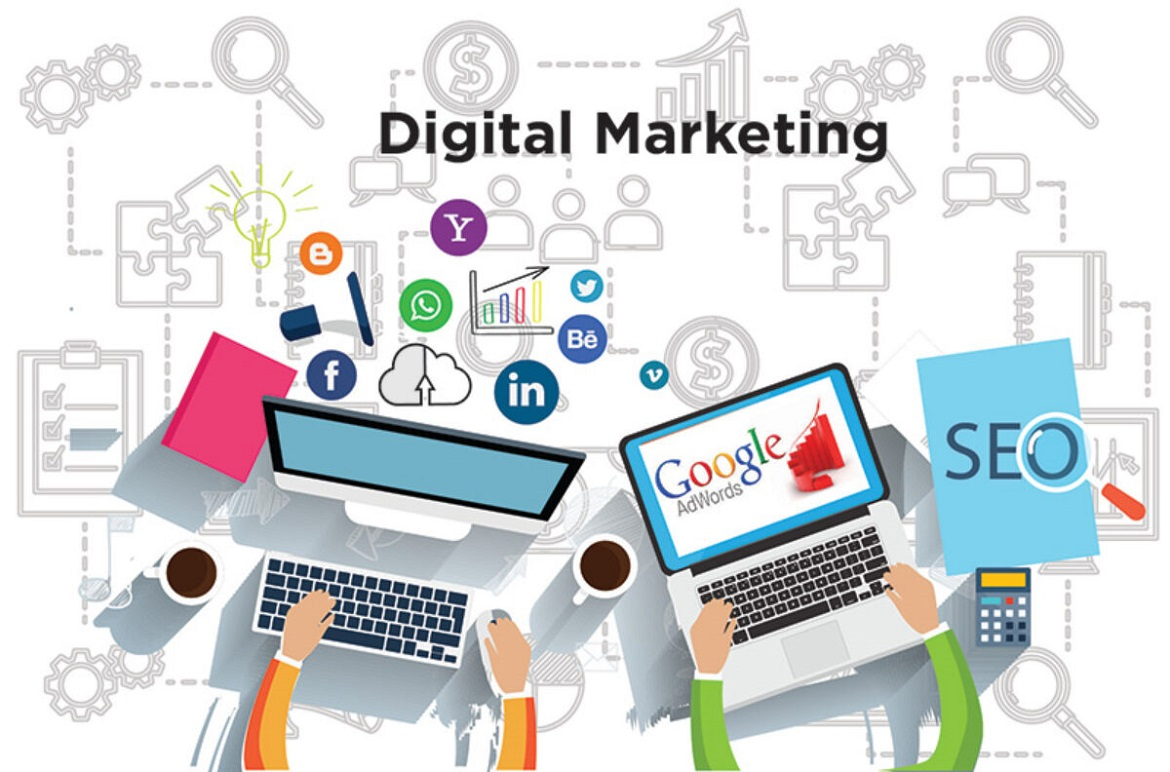



## **Bối cảnh**

Trong digital marketing, không phải chiến dịch nào cũng mang lại
giá trị như nhau. Một số chiến dịch tạo ra chuyển đổi có lợi nhuận,
trong khi những chiến dịch khác chỉ tiêu tốn ngân sách mà không
đem lại kết quả tương xứng.

Vì vậy, việc đánh giá hiệu quả chỉ dựa trên các chỉ số truyền thống
như tỷ lệ chuyển đổi hay chi phí mỗi lần mua (CPA) là chưa đủ để
đưa ra quyết định phân bổ ngân sách tối ưu.

---

## **Mục tiêu**

Dự án này xây dựng một framework phân tích dựa trên dữ liệu nhằm
tối ưu hóa quyết định phân bổ ngân sách quảng cáo thông qua:

- Ước tính xác suất chuyển đổi của từng khách hàng
- Chuyển đổi output của mô hình thành giá trị tài chính thực tế
- Tối đa hóa kỳ vọng lợi nhuận từ các hoạt động marketing

---

## **Phương pháp**

Thay vì tập trung vào độ chính xác của mô hình, dự án nhấn mạnh
vào giá trị kinh doanh thực tế thông qua các bước:

1. Xây dựng mô hình phân loại để dự báo xác suất chuyển đổi
2. Hiệu chỉnh xác suất dự báo (Calibration) để phản ánh thực tế tốt hơn
3. Ước tính Giá trị Vòng đời Khách hàng (LTV) theo từng cá nhân
4. Tính toán Kỳ vọng Giá trị (EV) làm chỉ số quyết định thống nhất

---

## **Framework Ra Quyết Định**

Mọi quyết định phân bổ ngân sách đều dựa trên công thức Kỳ vọng
Giá trị (Expected Value):

EV = P(chuyển đổi) × LTV − CAC

- Nếu EV > 0 → Chiến dịch sinh lời → Ưu tiên duy trì hoặc tăng ngân sách
- Nếu EV < 0 → Chiến dịch không hiệu quả → Xem xét giảm hoặc cắt ngân sách

---

## **Giới hạn của Dataset**

Dataset sử dụng là dữ liệu tổng hợp (synthetic data) với phân phối
đều trên tất cả các biến số — không có outlier, không có tương quan
tự nhiên giữa các đặc trưng.

Hai hàm ý quan trọng:

- **LTV** là proxy ước tính, không phải CLV tài chính thực tế
- **CAC** được giả định theo benchmark ngành ($50–$150),
  không dùng cột AdSpend trong dataset vì range $100–$9,997
  không phản ánh chi phí thu hút khách hàng thực tế

Vì vậy, các kết quả trong dự án mang tính **định hướng**,
không phải khuyến nghị tuyệt đối. Framework này có thể áp dụng
trực tiếp khi có dữ liệu giao dịch thực tế.

---

## **Kết quả Kỳ vọng**

Framework cho phép xác định chiến dịch nào đang hoạt động hiệu quả
và chiến dịch nào nên được xem xét giảm ngân sách — từ đó tối ưu
hóa phân bổ chi tiêu quảng cáo dựa trên dữ liệu thay vì cảm tính.

### Import Libraries

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

Load Dataset

Link Dataset:
https://www.kaggle.com/code/devraai/digital-marketing-campaign-analysis-and-prediction/notebook

In [40]:
file_path = '/content/marketing_campaign_ad.csv'
df = pd.read_csv(file_path)
display(df.head())

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


**Information Data**

In [41]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         8000 non-null   int64  
 1   Age                8000 non-null   int64  
 2   Gender             8000 non-null   object 
 3   Income             8000 non-null   int64  
 4   CampaignChannel    8000 non-null   object 
 5   CampaignType       8000 non-null   object 
 6   AdSpend            8000 non-null   float64
 7   ClickThroughRate   8000 non-null   float64
 8   ConversionRate     8000 non-null   float64
 9   WebsiteVisits      8000 non-null   int64  
 10  PagesPerVisit      8000 non-null   float64
 11  TimeOnSite         8000 non-null   float64
 12  SocialShares       8000 non-null   int64  
 13  EmailOpens         8000 non-null   int64  
 14  EmailClicks        8000 non-null   int64  
 15  PreviousPurchases  8000 non-null   int64  
 16  LoyaltyPoints      8000 

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


## **DATA TYPE**

In [42]:
df = df.drop(columns=['CustomerID'])
df['Conversion'] = df['Conversion'].astype('category')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                8000 non-null   int64   
 1   Gender             8000 non-null   object  
 2   Income             8000 non-null   int64   
 3   CampaignChannel    8000 non-null   object  
 4   CampaignType       8000 non-null   object  
 5   AdSpend            8000 non-null   float64 
 6   ClickThroughRate   8000 non-null   float64 
 7   ConversionRate     8000 non-null   float64 
 8   WebsiteVisits      8000 non-null   int64   
 9   PagesPerVisit      8000 non-null   float64 
 10  TimeOnSite         8000 non-null   float64 
 11  SocialShares       8000 non-null   int64   
 12  EmailOpens         8000 non-null   int64   
 13  EmailClicks        8000 non-null   int64   
 14  PreviousPurchases  8000 non-null   int64   
 15  LoyaltyPoints      8000 non-null   int64   
 16  Conver

**Unique Data**

In [43]:
cat_cols = ['CampaignChannel', 'CampaignType', 'Gender']

for col in cat_cols:
    print(f"\n Column: {col}")
    print("-" * 30)


    print("Unique values:")
    print(df[col].unique())

    print("\nValue counts:")
    print(df[col].value_counts(dropna=False))


    print("\nValues with leading/trailing spaces:")
    print(df[df[col].str.strip() != df[col]][col])


 Column: CampaignChannel
------------------------------
Unique values:
['Social Media' 'Email' 'PPC' 'Referral' 'SEO']

Value counts:
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: CampaignChannel, dtype: object)

 Column: CampaignType
------------------------------
Unique values:
['Awareness' 'Retention' 'Conversion' 'Consideration']

Value counts:
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: CampaignType, dtype: object)

 Column: Gender
------------------------------
Unique values:
['Female' 'Male']

Value counts:
Gender
Female    4839
Male      3161
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: Gender, dtype: object)


## **HANDLE MISSING VALUES**

In [44]:
df.isnull().sum()
df = df.dropna()

## **REMOVE DUPLICATES**

In [45]:
df.duplicated().sum()
df = df.drop_duplicates()

## **OUTLIERS**

In [46]:
num_cols = [
    'Income',
    'AdSpend',
    'WebsiteVisits',
    'TimeOnSite',
    'PagesPerVisit',
    'PreviousPurchases',
    'LoyaltyPoints'
]

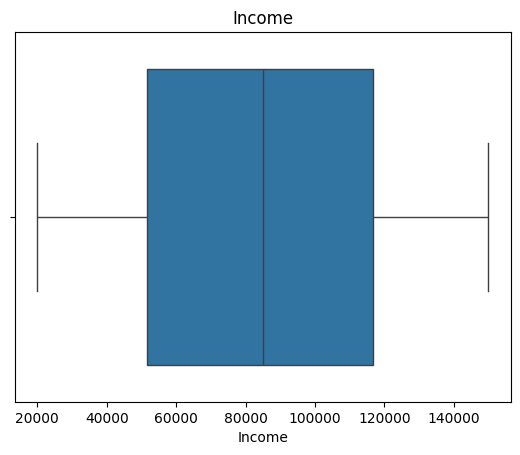

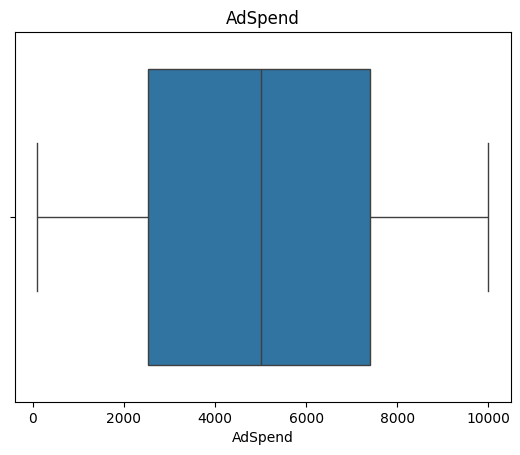

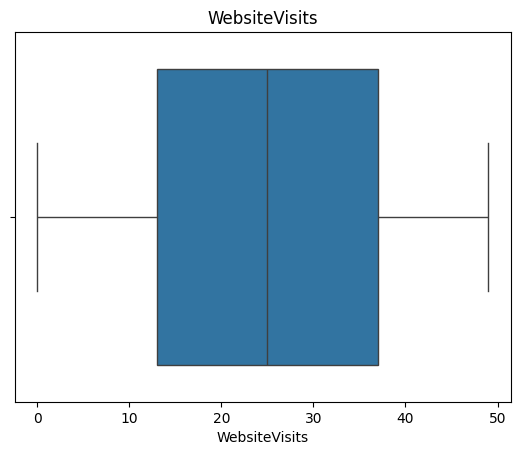

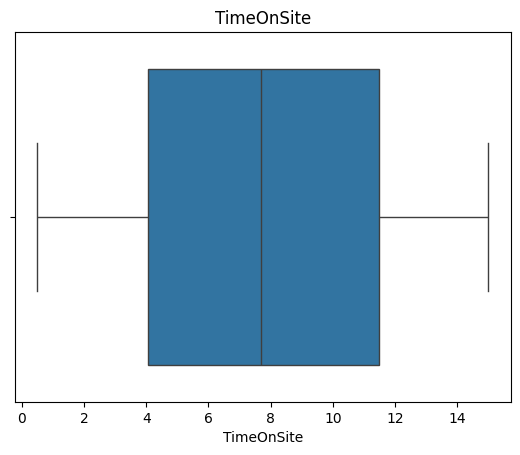

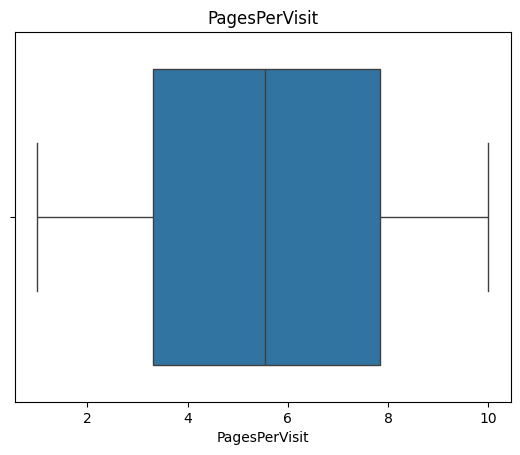

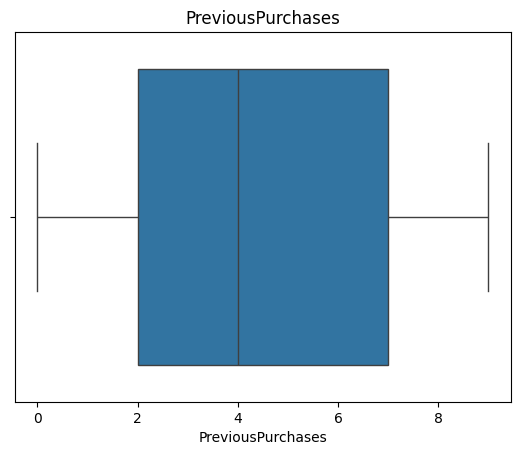

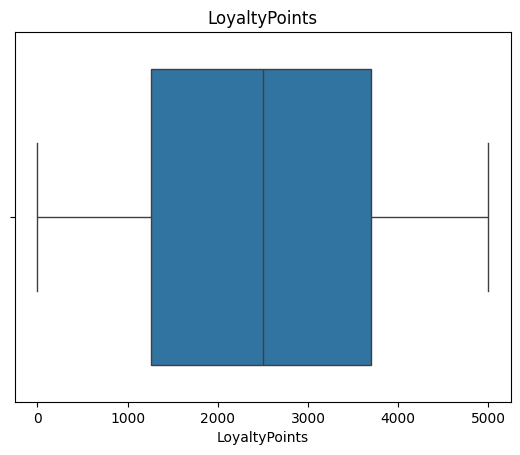

In [47]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Các biến số định lượng được lựa chọn bao gồm Income, AdSpend, WebsiteVisits, TimeOnSite, PagesPerVisit, PreviousPurchases và LoyaltyPoints không xuất hiện các outliers đáng kể. Điều này cho thấy dữ liệu có phân phối tương đối ổn định, không tồn tại các giá trị cực đoan có khả năng làm sai lệch quá trình huấn luyện mô hình.


In [48]:
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

find_outliers('Income')

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion


## **EDA (Exploratory Data Analysis)**

**Conversion**

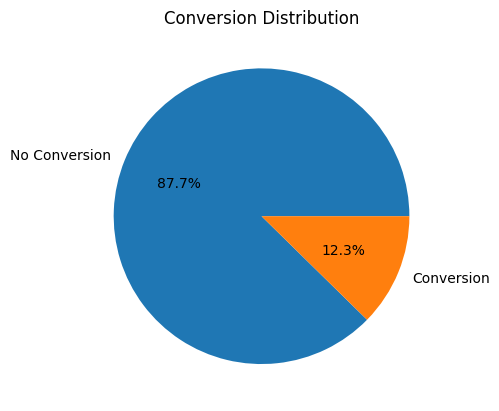

In [49]:
conversion_counts = df['Conversion'].value_counts()
labels = ['No Conversion', 'Conversion']
plt.figure()
plt.pie(
    conversion_counts,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title('Conversion Distribution')
plt.show()

> Dataset có tỷ lệ chuyển đổi rất cao (87.7%), cho thấy lớp Conversion chiếm ưu thế đáng kể so với No Conversion.

**Gender**

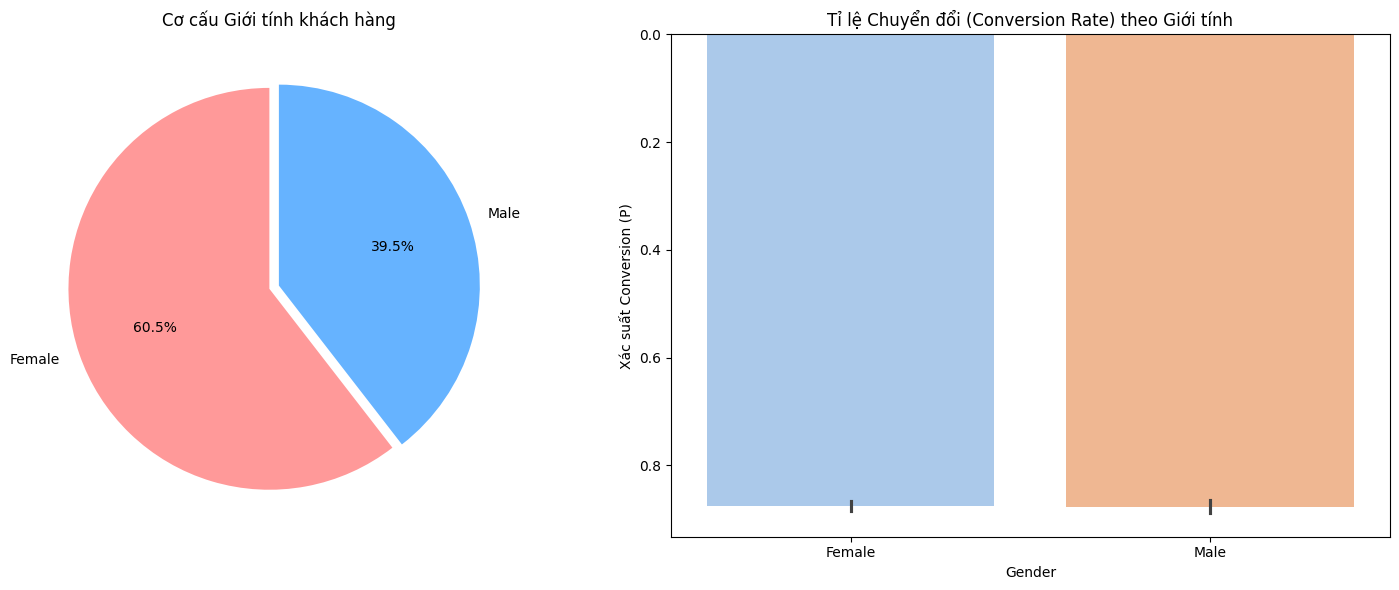

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
gender_counts = df['Gender'].value_counts()
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0))
ax1.set_title('Cơ cấu Giới tính khách hàng')
sns.barplot(x='Gender', y='Conversion', data=df, ax=ax2,
            hue='Gender', palette='pastel', legend=False)
ax2.set_title('Tỉ lệ Chuyển đổi (Conversion Rate) theo Giới tính')
ax2.set_ylabel('Xác suất Conversion (P)')
plt.tight_layout()
plt.show()

> Khách hàng nữ chiếm khoảng 60.5% tổng số quan sát, cao hơn khách hàng nam (39.5%). Tuy nhiên, tỷ lệ chuyển đổi giữa hai nhóm giới tính gần như tương đương, cho thấy giới tính không phải là yếu tố ảnh hưởng mạnh đến khả năng chuyển đổi.

**Age**

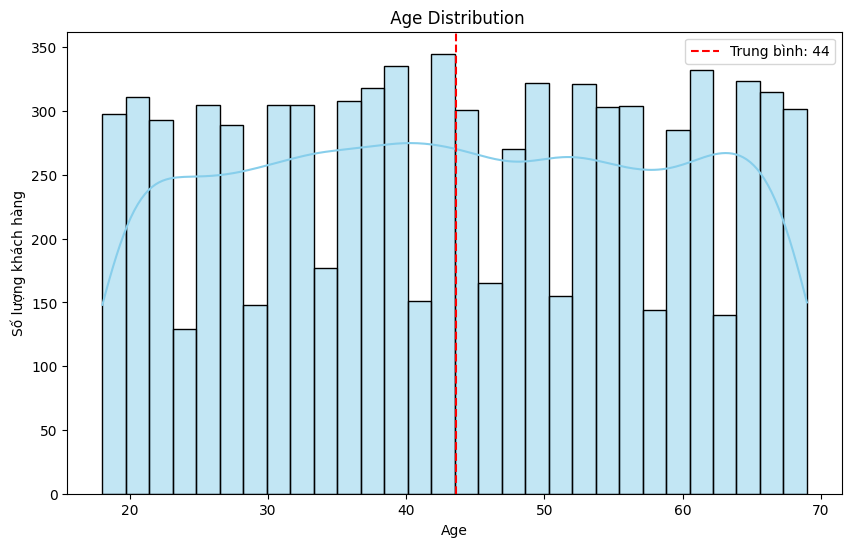

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=30)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Age'].mean():.0f}")
plt.title(' Age Distribution')
plt.xlabel('Age')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()

> Độ tuổi khách hàng phân bổ đều từ 18–70, trung bình 44 tuổi.
Không có nhóm tuổi nào chiếm ưu thế rõ rệt.

**Age and Conversion**

<Axes: xlabel='Age', ylabel='Density'>

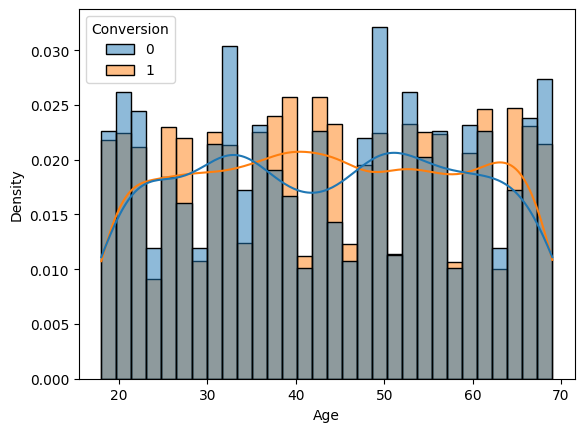

In [52]:
sns.histplot(
    data=df,
    x="Age",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

> Hai nhóm chuyển đổi và không chuyển đổi có phân phối tuổi
gần như giống nhau, cho thấy độ tuổi không ảnh hưởng đến
khả năng chuyển đổi của khách hàng.

**Distribution of AdSpend**

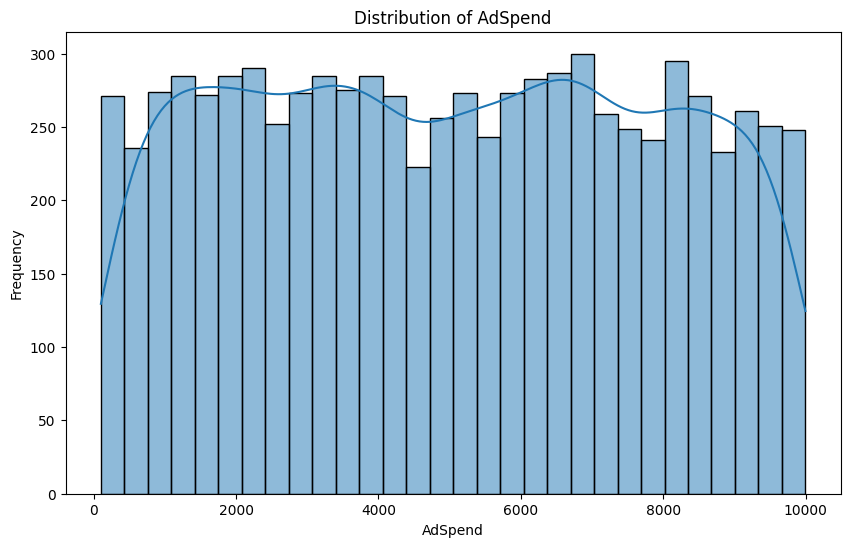

In [53]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='AdSpend',
    bins=30,
    kde=True
)

plt.title('Distribution of AdSpend')
plt.xlabel('AdSpend')
plt.ylabel('Frequency')

plt.show()

> Ngân sách quảng cáo phân bổ đều từ $0–$10,000, không có
mức chi tiêu nào nổi bật. Phân phối này cho thấy ngân sách
được phân bổ đồng đều giữa các khách hàng.

**AdSpend and Conversion**

<Axes: xlabel='AdSpend', ylabel='Density'>

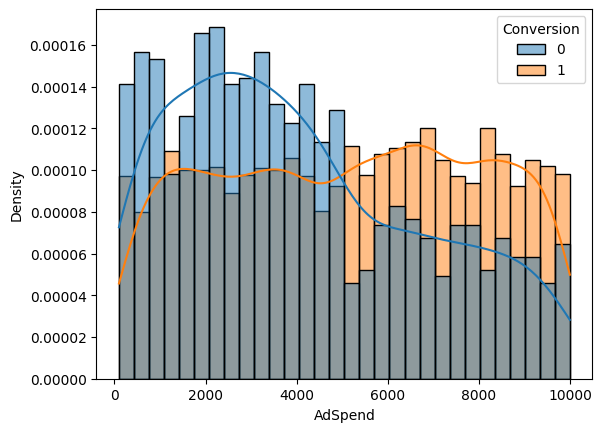

In [54]:
sns.histplot(
    data=df,
    x="AdSpend",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

> Nhóm không chuyển đổi tập trung ở mức AdSpend thấp, trong
khi nhóm chuyển đổi phân bổ rộng hơn về phía chi tiêu cao.
Tuy nhiên sự khác biệt không đủ rõ để kết luận AdSpend
là yếu tố quyết định chuyển đổi.

**Distribution of PreviousPurchases**

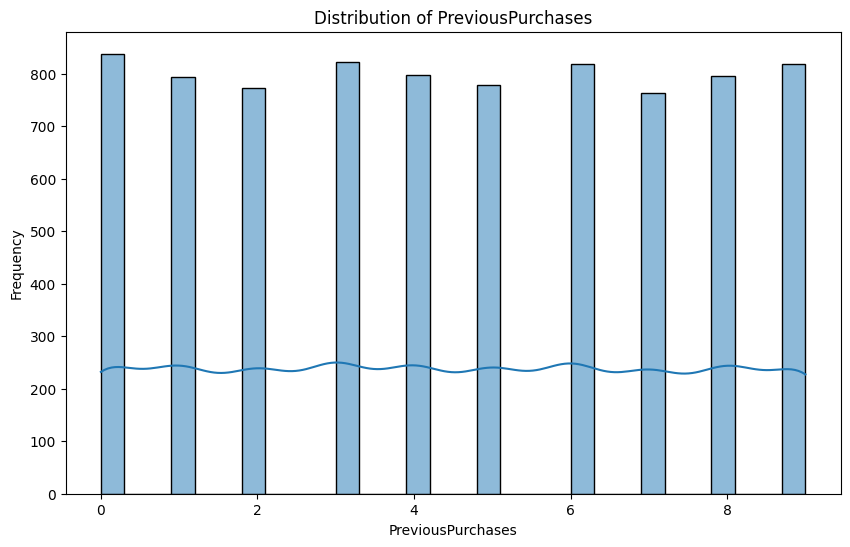

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='PreviousPurchases',
    bins=30,
    kde=True
)

plt.title('Distribution of PreviousPurchases')
plt.xlabel('PreviousPurchases')
plt.ylabel('Frequency')

plt.show()

Số lần mua trước phân bổ đều từ 0–9, mỗi mức có khoảng
800 khách hàng. Không có sự tập trung ở bất kỳ mức nào.

**PreviousPurchases and Conversion**

<Axes: xlabel='PreviousPurchases', ylabel='Density'>

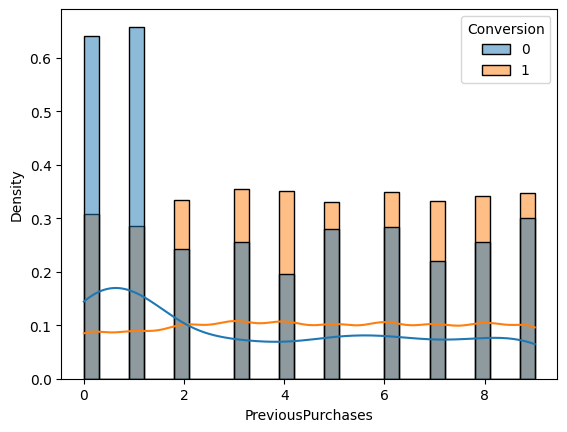

In [56]:
sns.histplot(
    data=df,
    x="PreviousPurchases",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

> Khách hàng có lịch sử mua hàng từ 2 lần trở lên có xu hướng
chuyển đổi cao hơn, trong khi nhóm không chuyển đổi tập trung
chủ yếu ở những khách hàng chưa có hoặc chỉ có 1 lần mua
trước đó. Điều này gợi ý rằng lịch sử mua hàng là tín hiệu
tích cực cho khả năng chuyển đổi.



**Income Distribution**



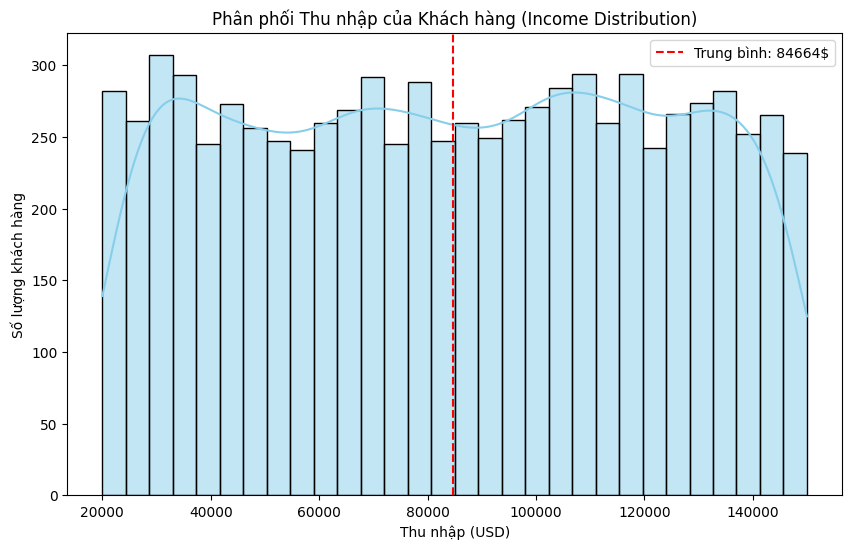

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], kde=True, color='skyblue', bins=30)
plt.axvline(df['Income'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Income'].mean():.0f}$")
plt.title('Phân phối Thu nhập của Khách hàng (Income Distribution)')
plt.xlabel('Thu nhập (USD)')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()

> Thu nhập khách hàng phân bổ đều từ $20,000–$150,000,
trung bình $84,664. Không có nhóm thu nhập nào chiếm ưu thế.

**Income and Conversion**

<Axes: xlabel='Income', ylabel='Density'>

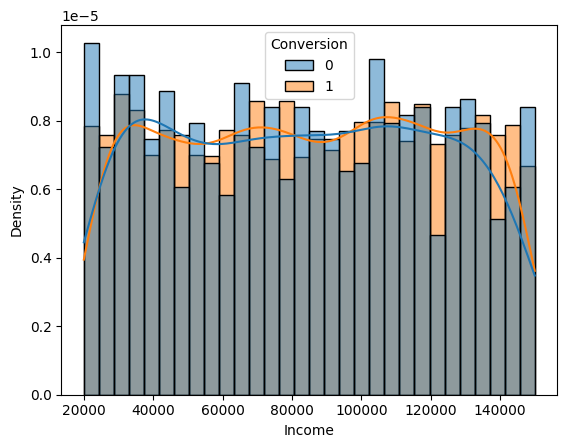

In [58]:
sns.histplot(
    data=df,
    x="Income",
    hue="Conversion",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

> Hai nhóm chuyển đổi và không chuyển đổi có phân phối thu nhập
gần như giống nhau. Thu nhập không phân biệt được khách hàng
có khả năng chuyển đổi hay không.

**Total AdSpend by Campaign**

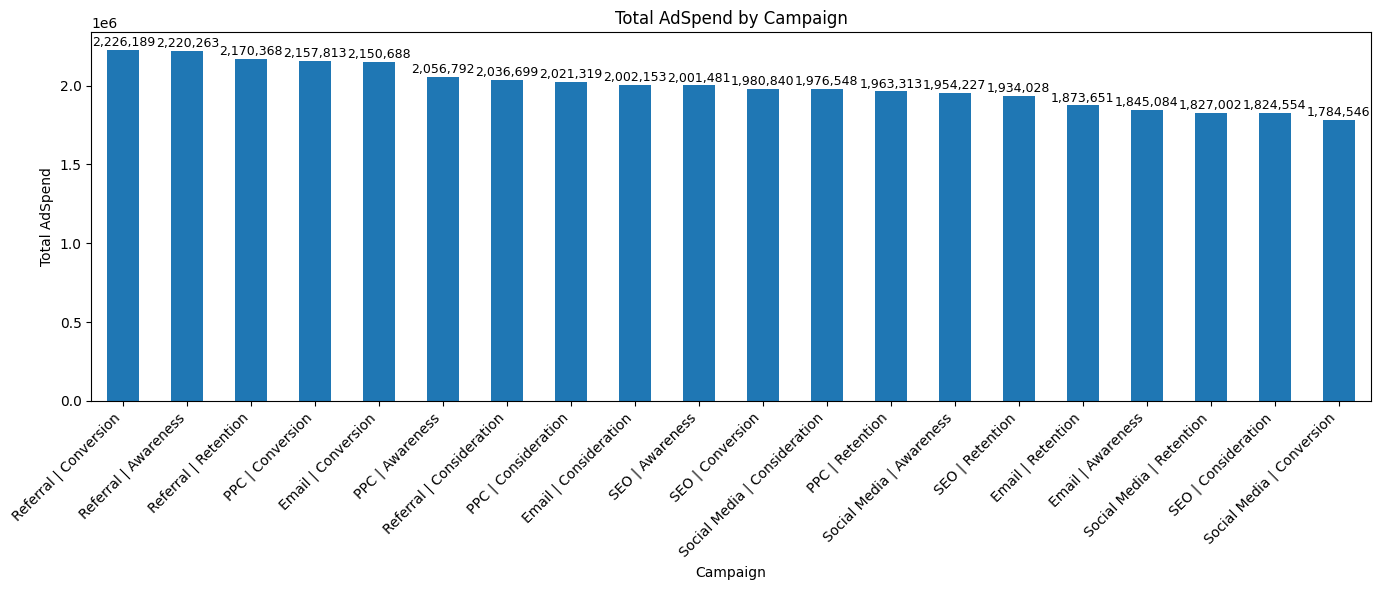

In [59]:
# Tạo campaign proxy
df["campaign"] = df["CampaignChannel"] + " | " + df["CampaignType"]

# Tổng AdSpend theo campaign
campaign_spend = (
    df.groupby("campaign")["AdSpend"]
      .sum()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(14,6))

ax = campaign_spend.plot(kind="bar")


for i, value in enumerate(campaign_spend):
    ax.text(
        i,
        value + 5000,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Total AdSpend by Campaign")
plt.ylabel("Total AdSpend")
plt.xlabel("Campaign")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

> Tổng ngân sách phân bổ gần như đồng đều cho tất cả 20 tổ hợp
chiến dịch, dao động từ $1.8M đến $2.2M. Không có chiến dịch
nào được ưu tiên ngân sách rõ rệt hơn các chiến dịch còn lại.

**Conversion Rate by Campaign**

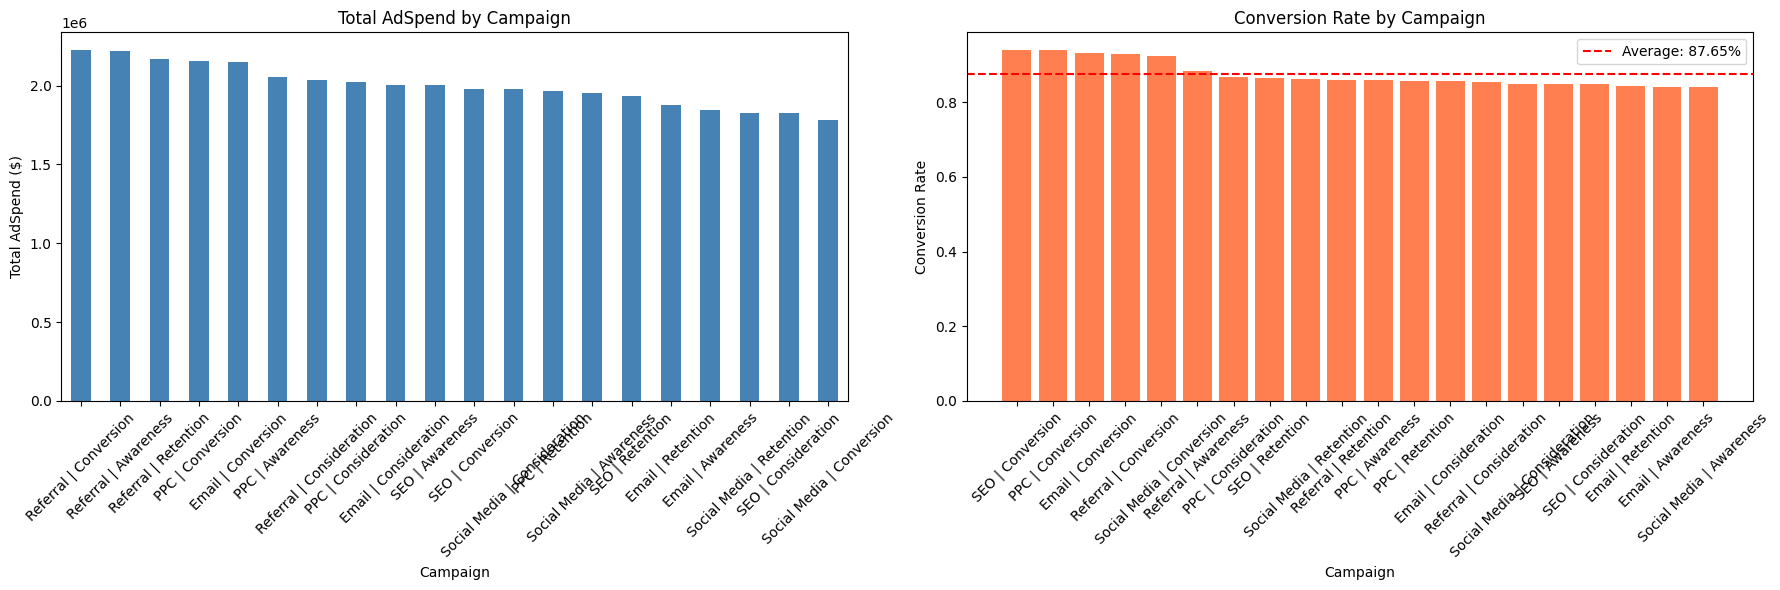

In [60]:
# Tính conversion rate theo campaign
campaign_conversion = df.groupby("campaign").agg(
    total_customers  = ("Conversion", "count"),
    total_converted  = ("Conversion", lambda x: (x.astype(int) == 1).sum()),
).reset_index()

campaign_conversion["conversion_rate"] = (
    campaign_conversion["total_converted"] /
    campaign_conversion["total_customers"]
)

campaign_conversion = campaign_conversion.sort_values(
    "conversion_rate", ascending=False
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Total AdSpend
campaign_spend = df.groupby("campaign")["AdSpend"].sum().sort_values(ascending=False)
campaign_spend.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total AdSpend by Campaign")
axes[0].set_ylabel("Total AdSpend ($)")
axes[0].set_xlabel("Campaign")
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Conversion Rate
axes[1].bar(
    campaign_conversion["campaign"],
    campaign_conversion["conversion_rate"],
    color="coral"
)
axes[1].set_title("Conversion Rate by Campaign")
axes[1].set_ylabel("Conversion Rate")
axes[1].set_xlabel("Campaign")
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(
    df["Conversion"].astype(int).mean(),
    color="red", linestyle="--",
    label=f'Average: {df["Conversion"].astype(int).mean():.2%}'
)
axes[1].legend()

plt.tight_layout()
plt.show()

> Tổng ngân sách quảng cáo phân bổ tương đối đồng đều giữa
20 tổ hợp chiến dịch, dao động từ $1.8M đến $2.2M — không
có chiến dịch nào được ưu tiên ngân sách rõ rệt hơn các
chiến dịch còn lại.

> Ở chiều ngược lại, tỷ lệ chuyển đổi của tất cả 20 chiến dịch
đều xoay quanh mức trung bình 87.65% và gần như không có sự
khác biệt đáng kể giữa các chiến dịch. Điều này cho thấy
conversion rate không phải là chỉ số đủ nhạy để phân biệt
hiệu quả giữa các chiến dịch trong dataset này.

> Khi kết hợp hai biểu đồ, có thể thấy ngân sách cao hơn
không đồng nghĩa với conversion rate cao hơn — đây là lý do
cần một framework đánh giá toàn diện hơn dựa trên Expected
Value thay vì chỉ nhìn vào tỷ lệ chuyển đổi đơn thuần.

**Mối quan hệ giữa các biến định lượng và Conversion**

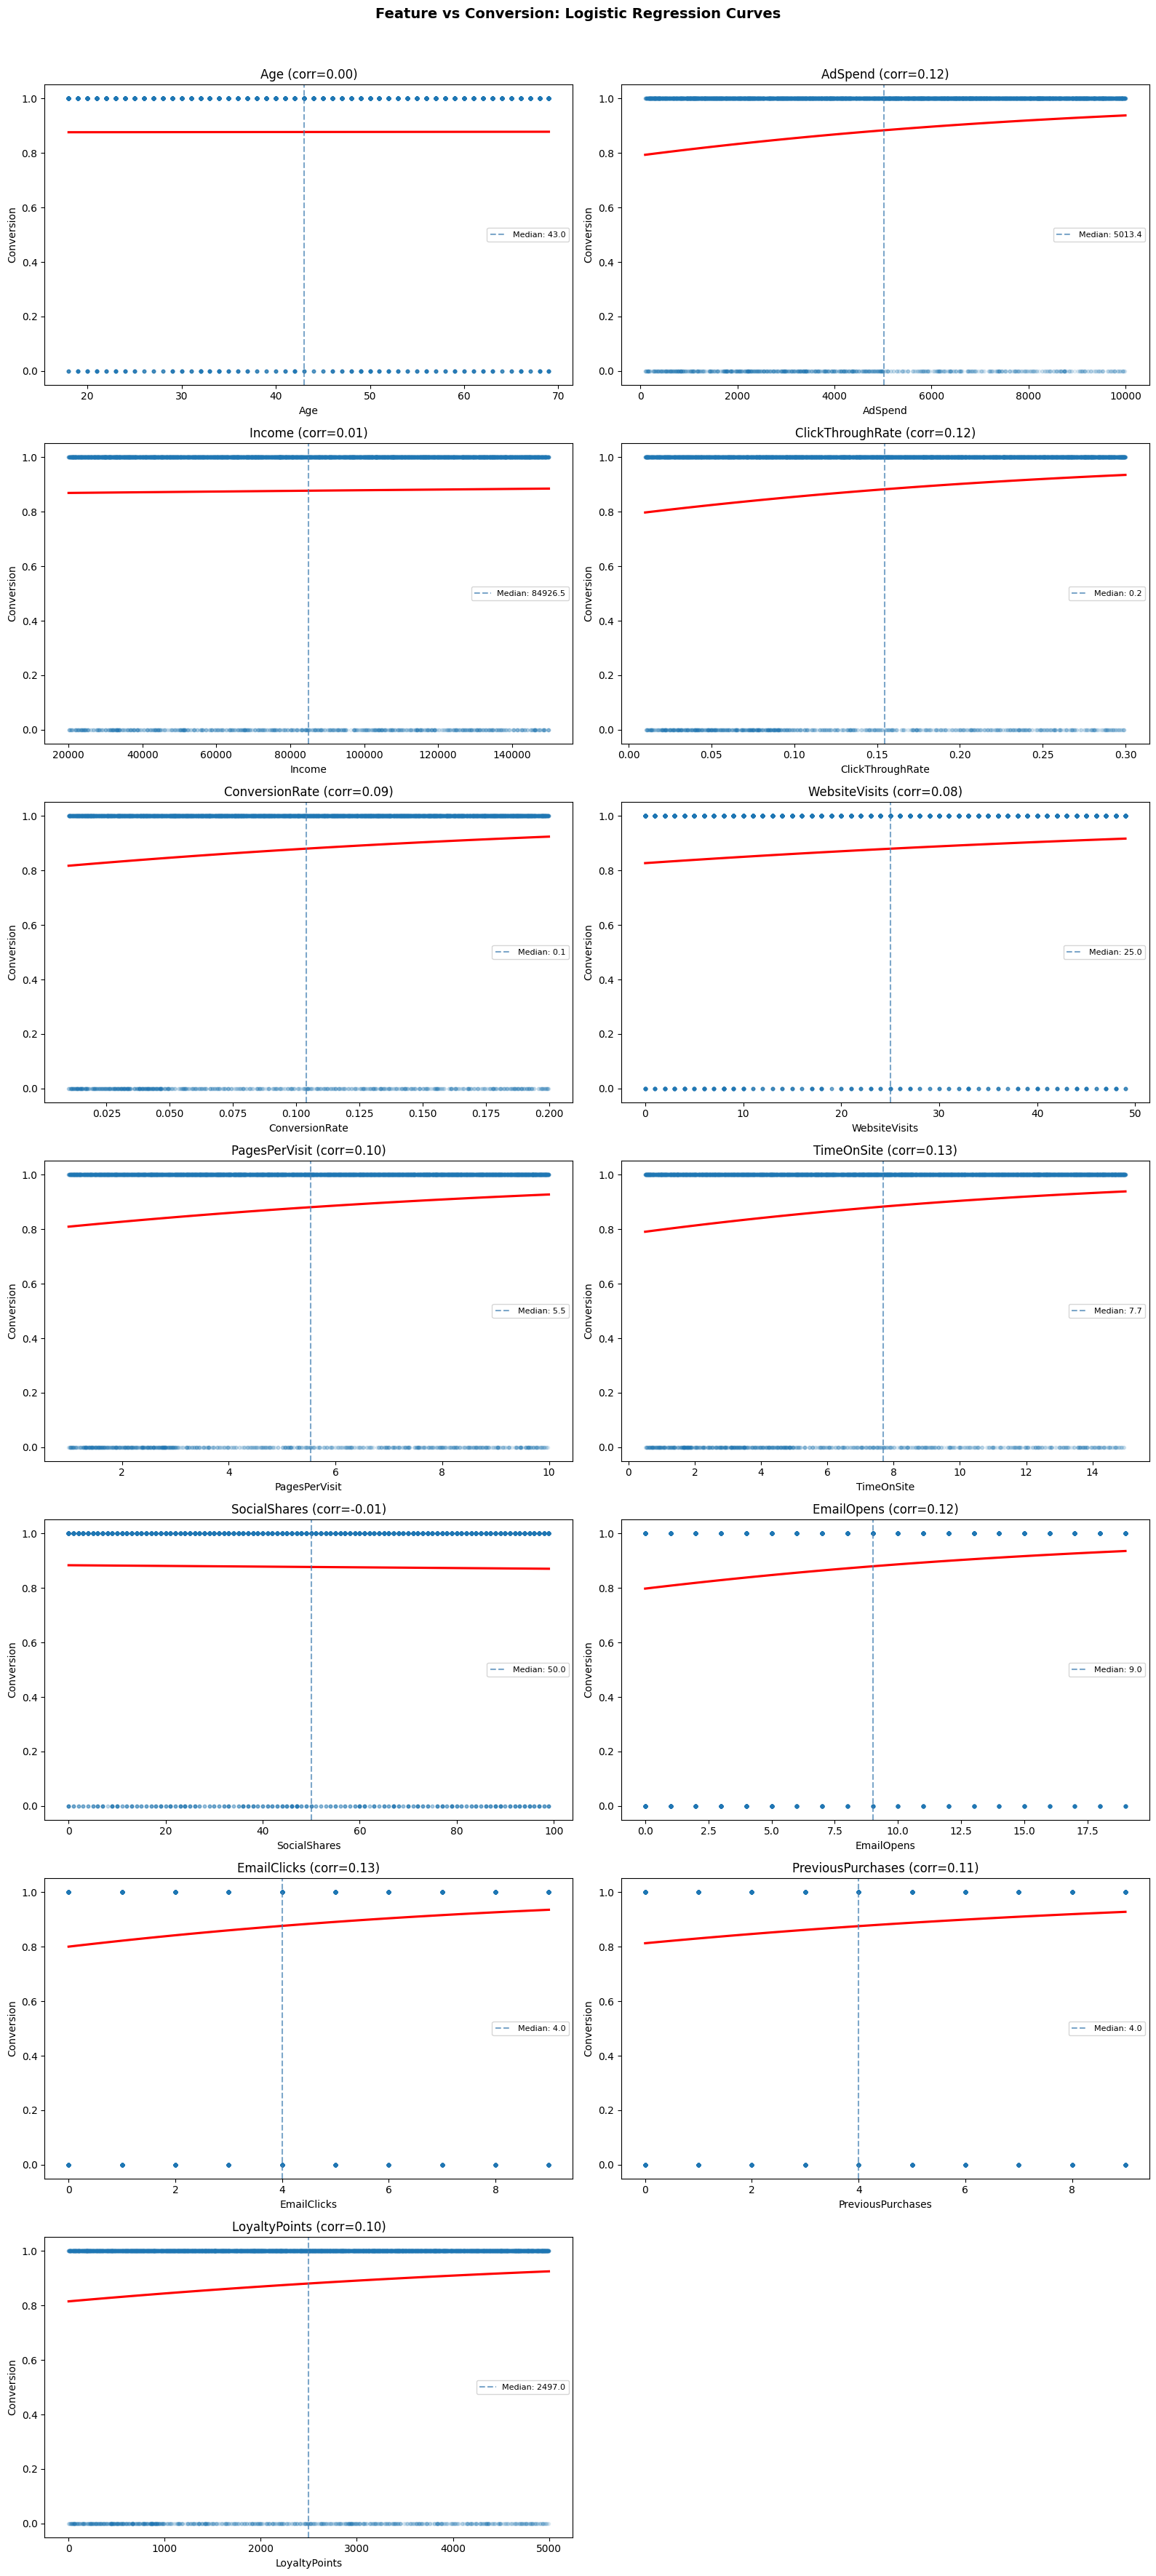

In [61]:
numeric_cols = [
    'Age','AdSpend','Income','ClickThroughRate', 'ConversionRate', 'WebsiteVisits',
    'PagesPerVisit', 'TimeOnSite', 'SocialShares',
    'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints'
]
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

df_plot = df.copy()
df_plot['Conversion'] = df_plot['Conversion'].astype(float)

for i, col in enumerate(numeric_cols):
    corr_value = df_plot[col].corr(df_plot['Conversion'])
    median_val = df_plot[col].median()

    sns.regplot(
        x=col, y='Conversion', data=df_plot,
        logistic=True, ci=None,
        scatter_kws={'alpha': 0.1, 's': 10},
        line_kws={'color': 'red'},
        ax=axes[i]
    )

    axes[i].axvline(median_val, linestyle='--', color='steelblue',
                    alpha=0.7, label=f'Median: {median_val:.1f}')
    axes[i].set_title(f'{col} (corr={corr_value:.2f})')
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature vs Conversion: Logistic Regression Curves',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Hầu hết các biến số trong tập dữ liệu chỉ có mức tương quan yếu với khả năng chuyển đổi khách hàng, với hệ số tương quan dao động khoảng từ 0.08 đến 0.13. Điều này cho thấy không có một biến riêng lẻ nào đủ mạnh để giải thích hoàn toàn hành vi chuyển đổi của khách hàng. Các biến liên quan đến hành vi và mức độ tương tác như TimeOnSite, PagesPerVisit, ClickThroughRate, EmailClicks, PreviousPurchases và LoyaltyPoints có mối quan hệ tích cực nhưng chỉ ở mức vừa phải với conversion. Ngược lại, các biến nhân khẩu học như Age và Income gần như không có ảnh hưởng đáng kể đến khả năng chuyển đổi, trong khi SocialShares cũng không cho thấy mối liên hệ rõ ràng với hành vi mua hàng thực tế. Nhìn chung, kết quả cho thấy conversion được hình thành từ sự kết hợp của nhiều tín hiệu tương tác khác nhau thay vì bị chi phối bởi một yếu tố nổi bật duy nhất.


-----

## **Ghi chú về chất lượng dữ liệu (Dataset Quality Note)**

Hầu hết các biến số đều có phân phối gần như đồng đều (uniform), với rất ít độ lệch (skewness) hoặc giá trị cực đoan (outliers).

Phân tích tương quan cho thấy mối quan hệ giữa nhiều biến là khá yếu.
Những đặc điểm này không phổ biến trong các bộ dữ liệu khách hàng thực tế và có thể là dấu hiệu cho thấy dữ liệu được tạo tổng hợp (synthetic data).
Vì vậy, các kết quả từ phân tích khám phá dữ liệu (EDA) và mô hình dự đoán nên được xem là những insight mang tính minh họa và định hướng, thay vì các kết luận kinh doanh mang tính khẳng định tuyệt đối.

----

### Dummies Category

In [62]:
df_model = pd.get_dummies(df, drop_first=True)

In [63]:
df_model.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,campaign_Referral | Conversion,campaign_Referral | Retention,campaign_SEO | Awareness,campaign_SEO | Consideration,campaign_SEO | Conversion,campaign_SEO | Retention,campaign_Social Media | Awareness,campaign_Social Media | Consideration,campaign_Social Media | Conversion,campaign_Social Media | Retention
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,...,False,False,False,False,False,False,True,False,False,False
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,...,False,False,False,False,False,False,False,False,False,False
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,...,False,False,False,False,False,False,False,False,False,False
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,...,False,False,False,False,False,False,False,False,False,False
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,...,False,False,False,False,False,False,False,False,False,False


## **MACHINE LEARNING**





### **Build model**

In [64]:
# Drop các columns bị leak hoặc không có ý nghĩa predictive thực tế


drop_cols = [
    'Conversion_1',    # target
    'ConversionRate',  # leakage
    'Gender_Male',     # no signal
    'Age',             # no signal
    'Income',         # no signal
    'SocialShares',   # no signal
    'WebsiteVisits'   # no signal
]

X = df_model.drop(columns=drop_cols)
y = df_model['Conversion_1']

### **Split Data 80:20**

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=3000, solver='saga')
model.fit(X_train_s, y_train)

y_prob = model.predict_proba(X_test_s)[:, 1]

### AUC

In [67]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob)

np.float64(0.7669157220161018)

In [68]:
comparison = pd.DataFrame({
    'Thực tế (Y)': y_test,
    'Xác suất dự báo (P-convert)': y_prob
})
print(comparison.head(20))

      Thực tế (Y)  Xác suất dự báo (P-convert)
2215        False                     0.871776
2582         True                     0.872767
1662         True                     0.727008
3027         True                     0.973689
4343         True                     0.893830
2680        False                     0.883186
1765         True                     0.959543
1123         True                     0.830717
4054        False                     0.770375
3761         True                     0.979202
1535         True                     0.970073
2944         True                     0.881792
2987        False                     0.742378
4291         True                     0.955176
4342         True                     0.849385
4424        False                     0.469481
7941         True                     0.898678
4997         True                     0.989318
2748         True                     0.603966
2302         True                     0.983177


## **Calibration**

In [69]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

base_model = LogisticRegression(max_iter=3000, solver='saga')
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=10)
calibrated_model.fit(X_train_scaled, y_train)

y_prob_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]

In [70]:
print("Before:", y_prob[:5])
print("After :", y_prob_calibrated[:5])

Before: [0.87177599 0.87276679 0.72700769 0.97368858 0.89382962]
After : [0.86975873 0.87104011 0.73324137 0.97028055 0.89151674]


###  **Plot Calibration Curve**

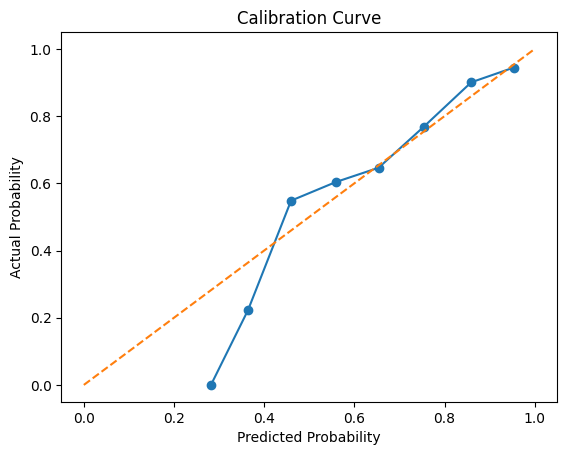

In [71]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_calibrated, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Calibration Curve')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')

plt.show()

> Biểu đồ Calibration Curve đánh giá mức độ tin cậy của xác suất dự báo từ mô hình, trong đó đường cam thể hiện kịch bản lý tưởng — nếu mô hình dự báo xác suất 0.Biểu đồ Calibration Curve đánh giá mức độ tin cậy của xác suất dự báo từ mô hình, trong đó đường cam thể hiện kịch bản lý tưởng — nếu mô hình dự báo xác suất 0.7 thì thực tế phải đúng 70% trường hợp. Đường xanh thể hiện xác suất thực tế quan sát được so với xác suất mô hình dự báo.

> Ở vùng xác suất cao từ 0.6 đến 1.0, đường xanh bám sát đường cam, cho thấy mô hình dự báo đáng tin cậy trong vùng này. Ở vùng xác suất thấp từ 0.3 đến 0.5, đường xanh lệch khỏi đường cam, cho thấy mô hình có xu hướng dự đoán cao hơn thực tế một chút. Tuy nhiên, sự lệch này ít ảnh hưởng đến kết quả tổng thể vì 87.65% khách hàng trong dataset có xác suất chuyển đổi cao — phần lớn dự báo nằm trong vùng 0.6–1.0 nơi mô hình hoạt động tốt nhất.

-----
## Phân tích Kỳ vọng Giá trị (Expected Value Analysis)

### LTV Proxy — không phải financial CLV thật
###  monthly_revenue = Income * 5% / 12 (wallet share assumption)
### retention_months = PreviousPurchases (replace 0→1)
### CAC = $50–$150 (industry benchmark, không phải AdSpend thật)



## Khung Giá trị Kỳ vọng (Expected Value Framework)

Giá trị Kỳ vọng (Expected Value - EV) kết hợp xác suất chuyển đổi (Conversion Probability), giá trị vòng đời khách hàng (Customer Lifetime Value - LTV) và chi phí thu hút khách hàng (Customer Acquisition Cost - CAC) thành một chỉ số duy nhất phục vụ cho việc ra quyết định kinh doanh.

Mặc dù bộ dữ liệu có chứa biến **AdSpend**, biến này không được sử dụng trực tiếp làm Chi phí Thu hút Khách hàng (CAC).

Nguyên nhân là bộ dữ liệu không cung cấp định nghĩa kinh doanh rõ ràng để xác định liệu **AdSpend** đại diện cho chi phí ở cấp độ chiến dịch (campaign-level spending), cấp độ nhóm quảng cáo (ad-set spending) hay chi phí thu hút của từng khách hàng (customer-level acquisition cost).

Do đó, nghiên cứu sử dụng các kịch bản CAC cố định (50 USD, 100 USD và 150 USD) nhằm đánh giá mức độ ổn định của các khuyến nghị kinh doanh dưới những giả định chi phí khác nhau.


In [72]:
test_index = y_test.index
df_test = df.loc[test_index].copy()
df_test["p_convert"] = y_prob_calibrated

df_test["retention_months"] = df_test["PreviousPurchases"].replace(0, 1)
df_test["monthly_revenue"]  = (df_test["Income"] * 0.05) / 12
df_test["LTV"]              = df_test["monthly_revenue"] * df_test["retention_months"]

CAC_LOW, CAC_HIGH = 50, 150
df_test["EV_low"]  = df_test["p_convert"] * df_test["LTV"] - CAC_LOW
df_test["EV_high"] = df_test["p_convert"] * df_test["LTV"] - CAC_HIGH

# Group by campaign
campaign_ev = df_test.groupby("CampaignChannel").agg(
    n_customers   = ("EV_low", "count"),
    mean_EV_low   = ("EV_low", "mean"),
    mean_EV_high  = ("EV_high", "mean"),
    mean_LTV      = ("LTV", "mean"),
    mean_p_convert= ("p_convert", "mean")
).round(2)

print(campaign_ev.sort_values("mean_EV_low"))

# Group by CampaignType cũng làm tương tự
campaign_type_ev = df_test.groupby("CampaignType").agg(
    n_customers   = ("EV_low", "count"),
    mean_EV_low   = ("EV_low", "mean"),
    mean_EV_high  = ("EV_high", "mean"),
    mean_p_convert= ("p_convert", "mean")
).round(2)

print(campaign_type_ev.sort_values("mean_EV_low"))
print()

                 n_customers  mean_EV_low  mean_EV_high  mean_LTV  \
CampaignChannel                                                     
Referral                 349      1330.68       1230.68   1544.27   
PPC                      351      1363.80       1263.80   1590.64   
Email                    300      1364.44       1264.44   1572.16   
Social Media             313      1364.53       1264.53   1599.85   
SEO                      287      1368.11       1268.11   1569.84   

                 mean_p_convert  
CampaignChannel                  
Referral                   0.87  
PPC                        0.88  
Email                      0.87  
Social Media               0.87  
SEO                        0.88  
               n_customers  mean_EV_low  mean_EV_high  mean_p_convert
CampaignType                                                         
Awareness              385      1296.45       1196.45            0.86
Consideration          394      1298.01       1198.01            0.8

> Các kênh quảng cáo có mức EV tương đối đồng đều nhau
(mean EV_low dao động $1,330–$1,368), cho thấy không có
kênh nào vượt trội rõ rệt so với các kênh còn lại.

> Referral có EV thấp nhất ($1,330) trong khi SEO cao nhất ($1,368),
nhưng khoảng cách chỉ ~$38 — không đủ để ra quyết định
cắt giảm một kênh cụ thể dựa trên channel-level alone.

> → Quyết định phân bổ ngân sách nên dựa trên tổ hợp
  Channel + CampaignType thay vì channel đơn lẻ.

In [73]:
# Tạo "campaign" = Channel + Type
df_test["campaign"] = df_test["CampaignChannel"] + " | " + df_test["CampaignType"]

campaign_ev = df_test.groupby("campaign").agg(
    n_customers    = ("EV_low", "count"),
    mean_EV_low    = ("EV_low", "mean"),
    mean_EV_high   = ("EV_high", "mean"),
    mean_LTV       = ("LTV", "mean"),
    mean_p_convert = ("p_convert", "mean"),
    total_adspend  = ("AdSpend", "sum")
).round(2).sort_values("mean_EV_low")

print(campaign_ev)

                              n_customers  mean_EV_low  mean_EV_high  \
campaign                                                               
PPC | Retention                        82      1045.79        945.79   
Referral | Awareness                   71      1111.47       1011.47   
Email | Awareness                      76      1126.46       1026.46   
Social Media | Consideration           85      1161.74       1061.74   
SEO | Retention                        79      1186.76       1086.76   
PPC | Consideration                    85      1298.13       1198.13   
SEO | Consideration                    61      1303.02       1203.02   
Social Media | Retention               67      1306.49       1206.49   
Referral | Conversion                  86      1318.48       1218.48   
Email | Consideration                  74      1351.18       1251.18   
Referral | Consideration               89      1380.40       1280.40   
SEO | Awareness                        76      1400.42       130

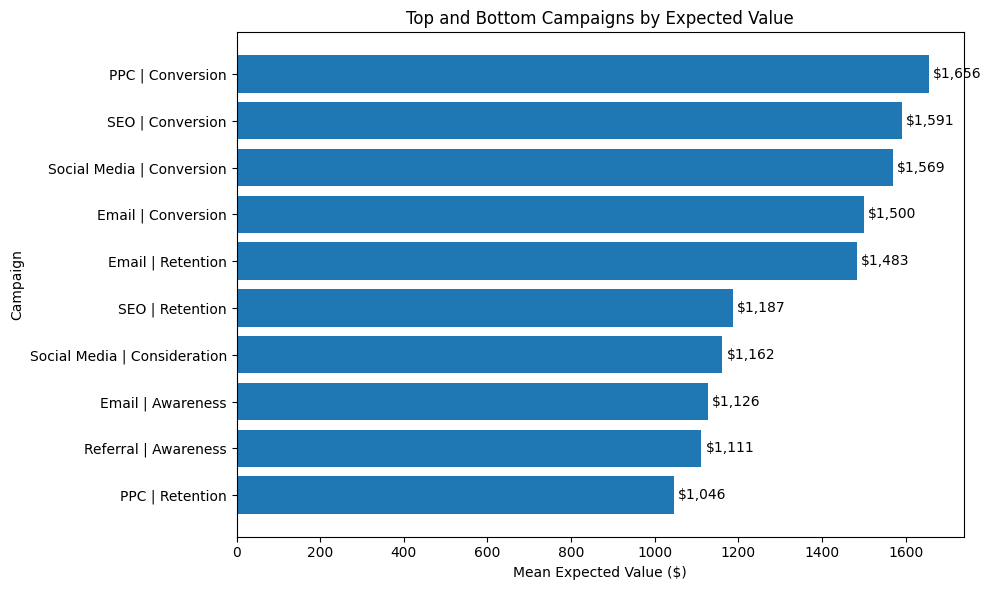

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
df = campaign_ev.copy()

# Sắp xếp theo EV
df_sorted = df.sort_values("mean_EV_low")

# Lấy Top 5 và Bottom 5
plot_df = pd.concat([
    df_sorted.head(5),
    df_sorted.tail(5)
])

plt.figure(figsize=(10,6))

bars = plt.barh(
    plot_df.index,
    plot_df["mean_EV_low"]
)

plt.xlabel("Mean Expected Value ($)")
plt.ylabel("Campaign")
plt.title("Top and Bottom Campaigns by Expected Value")

# Hiển thị giá trị
for bar in bars:
    plt.text(
        bar.get_width()+10,
        bar.get_y()+bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va='center'
    )

plt.tight_layout()
plt.show()

## **Insight : Khuyến nghị Phân bổ Ngân sách**

Khi phân tích tổ hợp kênh và mục tiêu chiến dịch, nhóm Conversion
campaigns nổi bật rõ ràng với EV cao nhất. Cụ thể, **PPC | Conversion**
dẫn đầu với mean EV đạt $1,656 và xác suất chuyển đổi 0.93, tiếp theo
là SEO | Conversion ($1,591, p_convert = 0.95) và Social Media |
Conversion ($1,569, p_convert = 0.93). Đây là nhóm nên được ưu tiên
duy trì hoặc tăng ngân sách nếu mục tiêu là tối đa hóa lợi nhuận
ngắn hạn.

Ở chiều ngược lại, **PPC | Retention** có EV thấp nhất trong toàn bộ
20 tổ hợp ($1,046), theo sau là Referral | Awareness ($1,111) và
Email | Awareness ($1,126). Nếu ngân sách có hạn và cần cắt giảm,
đây là nhóm nên được xem xét trước tiên.

Tuy nhiên, cần lưu ý rằng khoảng cách EV giữa nhóm cao nhất và
thấp nhất chỉ khoảng $600 — và sự chênh lệch này chủ yếu đến từ
LTV của customer segment, không hoàn toàn phản ánh hiệu quả thực
sự của chiến dịch. Nói cách khác, Conversion campaigns có EV cao
một phần vì chúng thu hút khách hàng có thu nhập và lịch sử mua
hàng tốt hơn, chứ không chắc vì bản thân chiến dịch hiệu quả hơn.

Vì vậy, khuyến nghị này mang tính định hướng và nên được kiểm
chứng bằng dữ liệu giao dịch thực tế trước khi ra quyết định
phân bổ ngân sách chính thức.

In [81]:
# 1. EV framework — chỉ cho Conversion + Retention
ev_campaigns = df_test[
    df_test["CampaignType"].isin(["Conversion", "Retention"])
].groupby(["CampaignChannel", "CampaignType"])[["EV_low", "EV_high"]].mean()

# 2. Engagement metrics — cho Awareness + Consideration
top_funnel = df_test[
    df_test["CampaignType"].isin(["Awareness", "Consideration"])
].groupby(["CampaignChannel", "CampaignType"])[
    ["TimeOnSite", "PagesPerVisit", "EmailClicks"]
].mean()

# 3. Sensitivity table
for cac in [50, 100, 150]:
    n = (df_test["p_convert"] * df_test["LTV"] - cac > 0).sum()
    print(f"CAC=${cac}: {n} customers positive EV")

CAC=$50: 1597 customers positive EV
CAC=$100: 1555 customers positive EV
CAC=$150: 1516 customers positive EV


## **Insight : Độ Bền của Kết quả theo CAC**

Để kiểm tra mức độ tin cậy của framework, phân tích độ nhạy
được thực hiện với ba mức CAC khác nhau: $50, $100 và $150 —
tương ứng với lower bound và upper bound của chi phí thu hút
khách hàng trong ngành digital marketing.

Kết quả cho thấy dù CAC tăng gấp 3 lần từ $50 lên $150,
số lượng customers có EV dương chỉ giảm khoảng 5% — từ
1,597 xuống 1,516. Điều này cho thấy kết quả phân tích
khá ổn định và không quá nhạy cảm với giả định về CAC.

Nguyên nhân là LTV trung bình của customers dao động trong
khoảng $1,400–$1,800, cao hơn đáng kể so với mức CAC được
giả định ($50–$150). Chính khoảng cách này giúp hầu hết
customers duy trì EV dương ngay cả ở mức CAC cao nhất.

Tuy nhiên, cần lưu ý rằng LTV ở đây là proxy ước tính
dựa trên wallet share assumption — không phải doanh thu
thực tế. Nếu LTV thực tế thấp hơn đáng kể so với ước tính,
kết quả có thể thay đổi đáng kể.
